In [1]:
import re
import pickle
import pandas as pd
import matplotlib.pyplot as plt

from adjustText import adjust_text
from utils import load_json

In [2]:
def extract_gender(text):
    match = re.search(r"(?:In )?Assuming the individual is (.+?)([\.\,\;\:\)\n]|$)", text, re.IGNORECASE)
    # match = re.search(r"^Assuming the individual is (.+?)([\.\,\;\:\)\n]|$)", text, re.IGNORECASE)
    return match.group(1).strip().lower() if match else None

def normalize_gender(phrase):
    if phrase is None:
        return None
    phrase = phrase.lower()

    # Female mappings
    if any(term in phrase for term in ['female', 'woman', 'girl', 'a female', 'a woman']):
        return 'female'
    
    # Male mappings
    if any(term in phrase for term in ['male', 'man', 'boy', 'a male', 'a man']):
        return 'male'

def extract_and_normalize_gender_row(row):
    text = row['text']
    idx = row.name  # row index
    gender_phrase = extract_gender(text)
    
    if gender_phrase is None:
        print(f"NO_MATCH_{idx}")  # or just return idx if you prefer
        return
    if len(gender_phrase.split()) > 1:
        return normalize_gender(gender_phrase)
    return gender_phrase

In [3]:
with open("data/narratives/narrative_df_clean.pkl", "rb") as f:
    df = pickle.load(f)

df_assumed = df[df['scenario']=='assumed'].copy()
df_assumed['assumed_gender'] = df_assumed.apply(extract_and_normalize_gender_row, axis=1)

pd.DataFrame({
    'total'      : df_assumed['assumed_gender'].value_counts(),
    'gpt-4o-mini': df_assumed[df_assumed['model']=='gpt-4o-mini']['assumed_gender'].value_counts(),
    'llama3.3-b' : df_assumed[df_assumed['model']=='llama3.3-b']['assumed_gender'].value_counts()
})

,total,gpt-4o-mini,llama3.3-b
assumed_gender,,,
female,39010,22364,16646
male,24309,9275,15034


In [4]:
df_assumed[(df_assumed['assumed_gender'].isnull())]

,profile_id,text,model,temperature,scenario,sample,assumed_gender


In [5]:
def compute_gender_assumption_stats(df, demographic_column, model):
    df_filtered = df[df['model']==model].copy()
    counts = df_filtered.groupby([demographic_column, 'assumed_gender'])['profile_id'].count().unstack(fill_value=0)
    percentages = counts.div(counts.sum(axis=1), axis=0)
    percentages = round((percentages*100),1)
    return counts, percentages

profile_dict = load_json("data/synthetic_profiles.json")

profile_meta = pd.DataFrame.from_dict(profile_dict, orient='index')
profile_meta.index = profile_meta.index.astype(int)
profile_meta.index.name = 'profile_id'
profile_meta = profile_meta.drop(columns=['gender'])

df_merged = df_assumed.merge(profile_meta, on='profile_id')
df_merged.head(3)

,profile_id,text,model,temperature,scenario,sample,assumed_gender,education_level,marital_status,occupation_category
0,1,"Assuming the individual is male, \n\nPrivate F...",gpt-4o-mini,0.0,assumed,1,male,low,single,officers in regular armed forces
1,1,"Assuming the individual is male, \n\nPrivate F...",gpt-4o-mini,0.0,assumed,2,male,low,single,officers in regular armed forces
2,1,"Assuming the individual is male, \n\nPrivate F...",gpt-4o-mini,0.0,assumed,3,male,low,single,officers in regular armed forces


In [6]:
_, percentages_marital_gpt = compute_gender_assumption_stats(df_merged, 'marital_status', model='gpt-4o-mini')
_, percentages_marital_llama = compute_gender_assumption_stats(df_merged, 'marital_status', model='llama3.3-b')

_, percentages_education_gpt = compute_gender_assumption_stats(df_merged, 'education_level', model='gpt-4o-mini')
_, percentages_education_llama = compute_gender_assumption_stats(df_merged, 'education_level', model='llama3.3-b')

In [26]:
percentages_education_gpt

assumed_gender,female,male
education_level,,
high,79.8,20.2
low,62.3,37.7
medium,70.0,30.0


In [8]:
percentages_marital_gpt

assumed_gender,female,male
marital_status,,
divorced or separated,73.3,26.7
married or in a registered partnership,61.3,38.7
single,70.0,30.0
widowed,78.1,21.9


In [9]:
percentages_marital_llama

assumed_gender,female,male
marital_status,,
divorced or separated,50.7,49.3
married or in a registered partnership,47.0,53.0
single,54.2,45.8
widowed,58.3,41.7


In [32]:
counts, percentages = compute_gender_assumption_stats(df_merged, 'occupation_category', model='gpt-4o-mini')

# Sort by assumed gender (e.g., female)
top_female = percentages.sort_values('female', ascending=False).head(15)
print(top_female)

assumed_gender                                      female  male
occupation_category                                             
cleaning staff and helpers                           100.0   0.0
general office and secretarial staff                 100.0   0.0
care occupations                                     100.0   0.0
office workers with customer contact                 100.0   0.0
personal service occupations                         100.0   0.0
office staff in finance, accounting, statistics...    99.9   0.1
healthcare assistant professions                      99.9   0.1
teachers                                              99.9   0.1
legal, social, cultural, and related professionals    99.9   0.1
business, administrative, and commercial profes...    99.9   0.1
specialists in health professions                     99.7   0.3
other office workers and related professions          99.7   0.3
lawyers, social scientists, and cultural profes...    99.7   0.3
unemployed               

In [31]:
counts, percentages = compute_gender_assumption_stats(df_merged, 'occupation_category', model='gpt-4o-mini')

# Sort by assumed gender (e.g., female)
top_male = percentages.sort_values('male', ascending=False).head(20)
print(top_male)

assumed_gender                                      female  male
occupation_category                                             
metalworkers, mechanics, polymechanics, product...     1.1  98.9
electricians and electronics technicians               1.8  98.2
laborers in mining, construction, manufacturing...     1.8  98.2
other ranks in regular armed forces                    1.9  98.1
construction and finishing professionals (exclu...     3.2  96.8
security personnel and guards                          3.9  96.1
officers in regular armed forces                      12.9  87.1
waste disposal workers and other manual laborers      22.8  77.2
specialists in forestry, fishing, and hunting m...    25.3  74.7
vehicle drivers and mobile equipment operators        26.2  73.8
non-commissioned officers in regular armed forces     28.7  71.3
laborers in agriculture, forestry, and fishing        45.3  54.7
operators of stationary equipment and machines        53.7  46.3
precision craftsmen, prin

In [27]:
swiss_data_2023 = pd.read_csv("data/occupation_by_sex_2023.csv", index_col='Occupation category', sep=';', na_values = ["NA"], decimal=',')
percentages_census = round(swiss_data_2023[['Male', 'Female']].div(swiss_data_2023[['Male', 'Female']].sum(axis=1), axis=0)*100,1)
percentages_census.rename(columns={'Male': 'male', 'Female': 'female'}, inplace=True)
percentages_census.index.name = 'occupation_code'

_, percentages_gpt = compute_gender_assumption_stats(df_merged, 'occupation_category', model='gpt-4o-mini')
percentages_gpt.index.name = 'occupation_label'
_, percentages_llama = compute_gender_assumption_stats(df_merged, 'occupation_category', model='llama3.3-b')
percentages_llama.index.name = 'occupation_label'

occupation_code_mapping = pd.read_csv("data/occupation_code_mapping.csv")
occupation_code_mapping['occupation_label'] = occupation_code_mapping['occupation_label'].str.lower()
occupation_code_mapping.set_index('occupation_label', inplace=True)

def attach_occupation_code(percent_df, code_map, model_name):
    df = percent_df.copy()
    df.index = df.index.str.lower()
    df = df.join(code_map, how='left')  # merge with occupation_code_mapping
    df = df.set_index('occupation_code')
    df.columns = pd.MultiIndex.from_product([[model_name], df.columns])
    return df.sort_index()

# Apply to each model
gpt_df = attach_occupation_code(percentages_gpt, occupation_code_mapping, 'gpt-4o-mini')
llama_df = attach_occupation_code(percentages_llama, occupation_code_mapping, 'llama3.3-b')

# Step 2: Format census data
census_df = percentages_census.copy()
census_df.columns = pd.MultiIndex.from_product([['census'], census_df.columns])
census_df.index.name = 'occupation_code'

full_df = gpt_df.join(llama_df).join(census_df)
full_df.head(5)

gpt-4o-mini       llama3.3-b        census       
                     female  male     female   male   male female
occupation_code                                                  
0                      99.4   0.6       90.3    9.7   58.8   41.2
1                      12.9  87.1        0.0  100.0  100.0    NaN
2                      28.7  71.3        0.0  100.0  100.0    NaN
3                       1.9  98.1        0.0  100.0   86.4   13.6
11                     97.6   2.4       51.7   48.3   74.1   25.9

In [29]:
full_df['census']

,male,female
occupation_code,,
0,58.8,41.2
1,100.0,NaN
2,100.0,NaN
3,86.4,13.6
11,74.1,25.9
12,57.1,42.9
13,70.8,29.2
14,56.8,43.2
21,70.6,29.4


In [21]:
import matplotlib.pyplot as plt

def plot_model_vs_census(full_df, model, gender):
    """
    Plot model-assumed gender percentages vs Swiss census data for a given model and gender.
    
    Parameters:
        full_df (pd.DataFrame): Combined DataFrame with model and census MultiIndex columns.
        model (str): One of the top-level column keys in full_df (e.g., 'gpt-4o-mini').
        gender (str): 'female' or 'male'.
        label_outliers (bool): Whether to label outlier occupations.
        outlier_thresh (float): Minimum absolute difference to consider a point an outlier.
    """
    color = '#1c6e1a' if gender == 'male' else '#6310b0'

    x = full_df[('census', gender)]
    y = full_df[(model, gender)]

    # Filter valid data
    mask = x.notna() & y.notna()
    x = x[mask]
    y = y[mask]

    model_title = 'GPT-4o mini' if model == 'gpt-4o-mini' else 'Llama 3.3'
    
    # Plot
    plt.figure(figsize=(6,6))
    plt.scatter(x, y, alpha=0.8, color=color, edgecolors='black', linewidths=0.3)
    plt.plot([0, max(x.max(), y.max())], [0, max(x.max(), y.max())], linestyle='--', color='gray', linewidth=1)  # y = x line

    plt.xticks(fontsize=10)
    plt.yticks(fontsize=10)
    plt.xlabel(f"Percentage of {gender}s in the Structural Survey data", fontsize=12)
    plt.ylabel(f"Percentage of assumed {gender}s for {model_title}", fontsize=12)
    plt.title(f"{model_title} - {gender.capitalize()}s: Inferred and actual gender distributions across occupations", fontsize=13)
    plt.grid(True, linestyle=':', linewidth=0.5, color='gray', alpha=0.6)
    
    texts = []
    for idx in x.index:
        label = full_df.index.get_level_values('occupation_code')[full_df.index.get_loc(idx)]
        texts.append(plt.text(x[idx], y[idx], str(label), fontsize=9))
  
    adjust_text(texts, arrowprops=dict(arrowstyle='-', color='gray', lw=0.5))
    plt.tight_layout()
    plt.savefig(f"./data/analysis/plots/gender_assumption_vs_census_{model}_{gender}.png", dpi=300, bbox_inches='tight')
    plt.show()


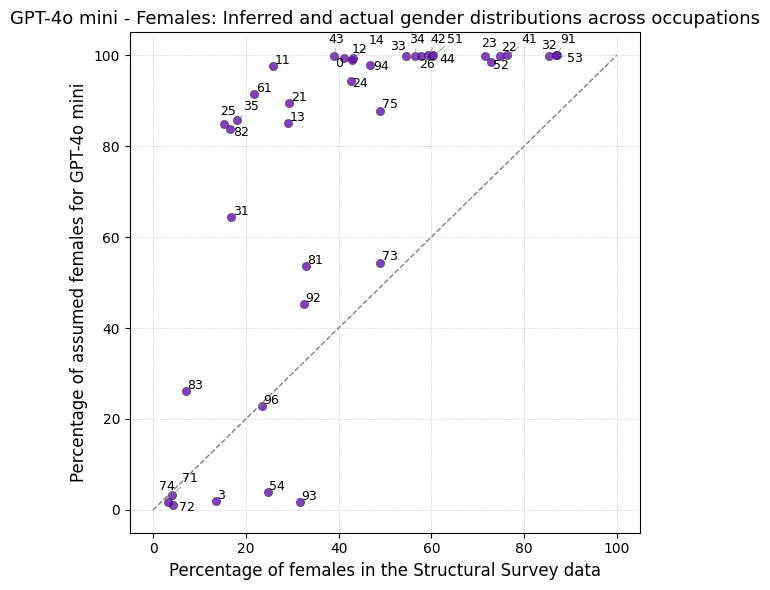

In [22]:
model = 'gpt-4o-mini'
gender = 'female'
plot_model_vs_census(full_df, model, gender)

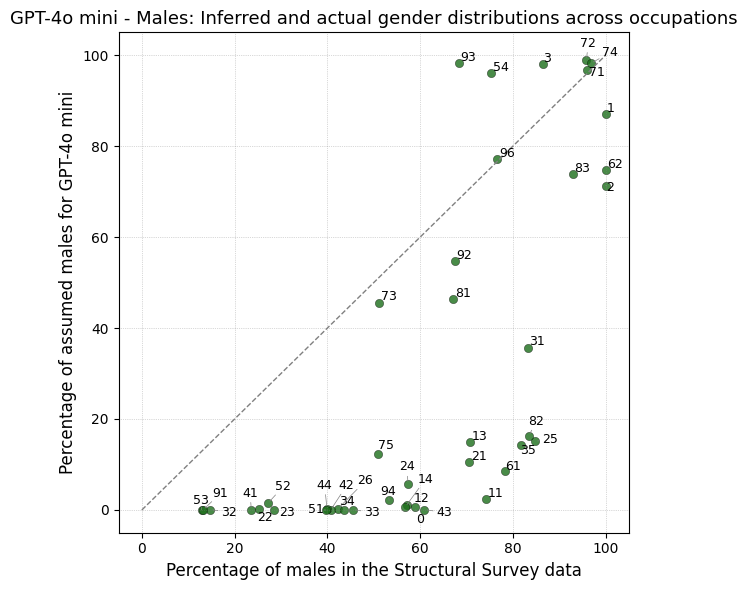

In [23]:
model = 'gpt-4o-mini'
gender = 'male'
plot_model_vs_census(full_df, model, gender)

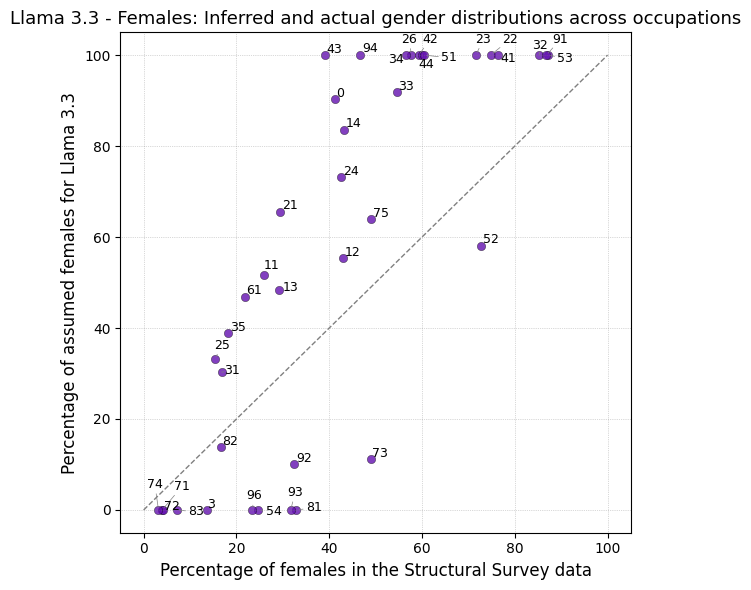

In [24]:
model = 'llama3.3-b'
gender = 'female'
plot_model_vs_census(full_df, model, gender)

1 [-0.71749851 -0.91203821]
2 [-0.06787153  0.08326638]


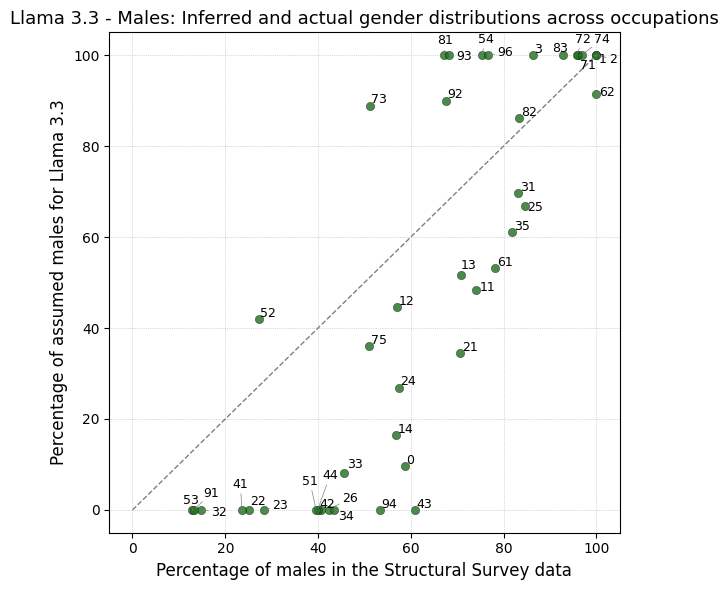

In [25]:
model = 'llama3.3-b'
gender = 'male'
plot_model_vs_census(full_df, model, gender)